# Predicting Temperatures Using Recurrent Neural Networks


<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<a href="https://colab.research.google.com/github/DeepTrackAI/DeepLearningCrashCourse/blob/main/Ch07_RNN/ec07_1_rnn/rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
<strong>If using Colab/Kaggle:</strong> You need to uncomment the code in the cell below this one.
You need also to copy the "jena_climate_2009_2016.csv" file from the
<a href="https://github.com/DeepTrackAI/DeepLearningCrashCourse/tree/main/Ch07_RNN/ec07_1_rnn">notebook folder</a> in GitHub to the Colab/Kaggle work directory.
</div>

In [1]:
# !pip install deeplay deeptrack  # Uncomment if using Colab/Kaggle.

This notebook provides you with a complete code example that uses different kinds of recurrent neural networks to predict the temperature in the Jena Climate Dataset.

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<strong>Note:</strong> This notebook contains the Code Example 7-1 from the book  

**Deep Learning Crash Course**  
Giovanni Volpe, Benjamin Midtvedt, Jesús Pineda, Henrik Klein Moberg, Harshith Bachimanchi, Joana B. Pereira, Carlo Manzo  
No Starch Press, San Francisco (CA), 2026  
ISBN-13: 9781718503922  

[https://nostarch.com/deep-learning-crash-course](https://nostarch.com/deep-learning-crash-course)

You can find the other notebooks on the [Deep Learning Crash Course GitHub page](https://github.com/DeepTrackAI/DeepLearningCrashCourse).
</div>

## Understanding Recurrent Relations

Implement a comb filter ...

In [2]:
# input_series = [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]

# hidden_state, U, V = 0, 0.5, 0.5

# output_series = []
# for input_data in input_series:
#     hidden_state = U * input_data + V * hidden_state
#     output_data = hidden_state
#     output_series.append(output_data)

# print(f"Output Series: {[f'{x:.2f}' for x in output_series]}")

... and transform it into a simple recurrent neural network (which generates some meaningless output because of the random initialization of its weights).

In [3]:
import numpy as np

def sigmoid(x):
    """Simple implementation of sigmoid function."""
    return 1 / (1 + np.exp(-x))

# input_series = [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]

# hidden_state = 0
# U, V, W, b = np.random.normal(size=4)

# output_series = []
# for input_data in input_series:
#     hidden_state = sigmoid(U * input_data + V * hidden_state + b)
#     output_data = sigmoid(W * hidden_state)
#     output_series.append(output_data)

# print(f"Output Series: {[f'{x:.2f}' for x in output_series]}")

## Downloading the Jena Climate Dataset

This dataset contains timeseries recorded at the weather station of the Max Planck Institute for Biogeochemistry in Jena, Germany. It’s made up of 14 different quantities recorded every 10 minutes over several years, from January 1st 2009 to December 31st 2016.

Load the Jena Climante Dataset ...

In [4]:
import pandas as pd

dataframe = pd.read_csv("jena_climate_2009_2016.csv", index_col=0)
data = dataframe.values
header = dataframe.columns.tolist()

... and display its header and first few elements.

In [5]:
print(dataframe.head())

                     p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
Date Time                                                                
01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

                     VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  \
Date Time                                                                  
01.01.2009 00:10:00          3.33          3.11          0.22       1.94   
01.01.2009 00:20:00          3.23          3.02          0.21       1.89   
01.01.2009 00:30:00          3.21          3.01          0.20       1.88   
01.01.2009 00:40:00          3.26          3.07          0.19       1.92   
01.01.2009 00:50:00      

### Visualizing the Data

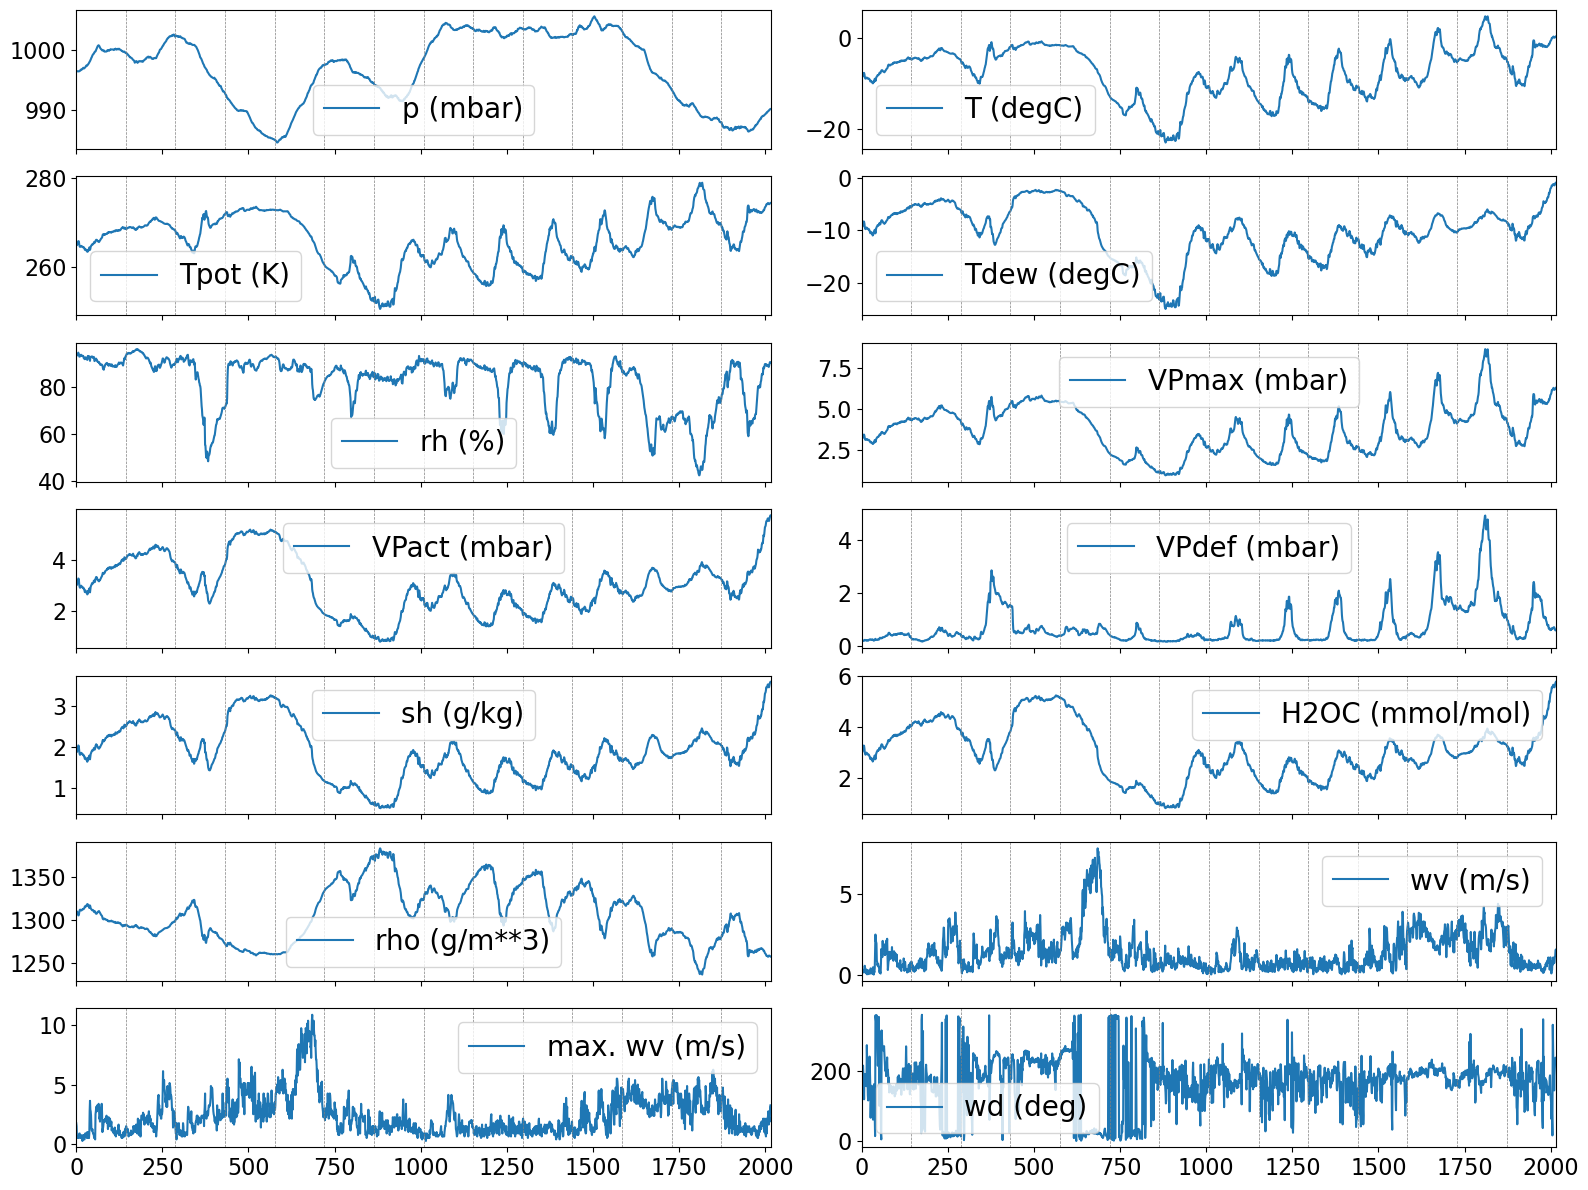

In [6]:
import matplotlib.pyplot as plt
import numpy as np

start, days, daily_samples = 0, 14, 144
end = start + daily_samples * days

fig, axs = plt.subplots(7, 2, figsize=(16, 12), sharex=True)
for i, ax in enumerate(axs.flatten()):
    ax.plot(np.arange(start, end), data[start:end, i], label=header[i])
    ax.set_xlim(start, end)
    ax.tick_params(axis="both", which="major", labelsize=16)
    ax.legend(fontsize=20)

    for day in range(1, days):
        ax.axvline(x=start + daily_samples * day,
                   color="gray", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

### Preprocessing the Data

Reshape the data in a format ready to train a recurrent neural network ...

In [7]:
n_samples, n_features = data.shape[0], data.shape[1]
past_seq = 2 * daily_samples
lag = 72
temp_idx = 1  # Temperature (Celsius) index

in_sequences, targets = [], []
for i in range(past_seq, n_samples - lag, daily_samples):
    in_sequences.append(data[i - past_seq:i, :])
    targets.append(data[i + lag:i + lag + 1, temp_idx])
in_sequences, targets = np.asarray(in_sequences), np.asarray(targets)

... check the input shape ...

In [8]:
print(in_sequences.shape)

(2918, 288, 14)


... check the output shape ...

In [9]:
print(targets.shape)

(2918, 1)


... split the data ...

In [10]:
import deeptrack as dt

sources = dt.sources.Source(inputs=in_sequences, targets=targets)
train_sources, val_sources = dt.sources.random_split(sources, [0.8, 0.2])

... normalize the data ...

In [11]:
import torch

train_mean = np.mean([src["inputs"] for src in train_sources], axis=(0, 1))
train_std = np.std([src["inputs"] for src in train_sources], axis=(0, 1))

inputs_pipeline = (dt.Value(sources.inputs - train_mean) / train_std
                   >> dt.pytorch.ToTensor(dtype=torch.float))
targets_pipeline = (dt.Value(sources.targets - train_mean[temp_idx]) 
                    / train_std[temp_idx])

... and define the data loaders.

In [12]:
from torch.utils.data import DataLoader

train_dataset = dt.pytorch.Dataset(inputs_pipeline & targets_pipeline,
                                   inputs=train_sources)
val_dataset = dt.pytorch.Dataset(inputs_pipeline & targets_pipeline,
                                 inputs=val_sources)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Visalizing embedding

In [ ]:
import torch
import torch.nn as nn

M = 6  # experiment with values between 5–100

# in_sequences shape: (batch, seq_len=288, n_features=14)
# Project N features → M dimensions
# embedding_proj = nn.Linear(in_features=n_features, out_features=M)
embedding_layer = nn.Linear(in_features=n_features, out_features=M)

sample_batch = torch.tensor(in_sequences[:1], dtype=torch.float32)  # (1, 288, 14)

C:\Users\jojac\AppData\Local\Temp\ipykernel_6104\2018917016.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sample_batch = torch.tensor(in_sequences[:1], dtype=torch.float32)  # (1, 288, 14)


tensor([-0.1168, -0.3164, -0.0984,  0.3692,  0.7674, -0.1763,  0.9720,  0.3967,
         0.1344,  0.1994,  0.1214,  0.5981, -0.6966,  0.9307,  0.0127,  0.9195,
        -0.2151,  0.2114,  0.4500, -0.5757], grad_fn=<SelectBackward0>)


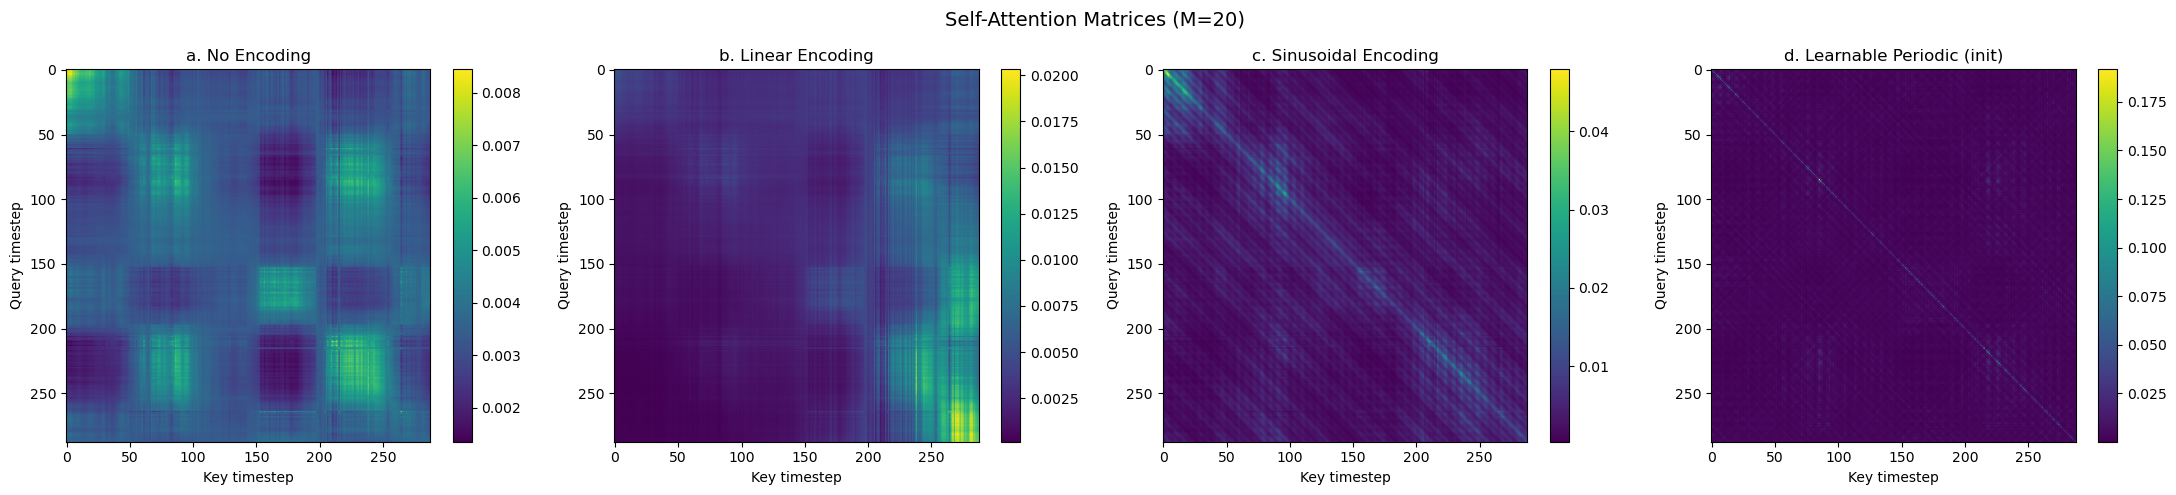

In [ ]:


# Apply to one batch for visualization

# embedded = embedding_proj(sample_batch)  # (1, 288, M)
embedded = embedding_layer(sample_batch)  # (1, 288, M)

print(embedded[0][0])

# a
x_no_enc = embedded  # shape: (1, L, M), no positional info added
# x_no_enc = torch.softmax(x_no_enc, dim=-1)

# b
L = embedded.shape[1]  # sequence length = 288

# PE(i) = i/L, shape: (1, L, 1) → broadcast to (1, L, M)
pe_linear = (torch.arange(L).float() / L).unsqueeze(0).unsqueeze(-1)  # (1, L, 1)
x_linear_enc = embedded + pe_linear  # adds i/L to every dimension
# x_linear_enc = torch.softmax(x_linear_enc, dim=-1)

def get_attention_matrix(x):
    with torch.no_grad():
        scores = torch.matmul(x, x.transpose(-2, -1)) / np.sqrt(x.shape[2])  # (batch, seq_len, seq_len)
        attM = torch.softmax(scores, dim=-1)
        return attM

def sinusoidal_pe(L, d_m):
    """
    Returns positional encoding of shape (1, L, d_m).
    PE(i, j) = sin(i / 10000^(j/d_m))  for j even
    PE(i, j) = cos(i / 10000^(j/d_m))  for j odd
    """
    pe = torch.zeros(L, d_m)
    positions = torch.arange(L).float().unsqueeze(1)          # (L, 1)
    dims = torch.arange(0, d_m, 2).float()                    # even indices only
    div_term = 10000 ** (dims / d_m)                          # (d_m/2,)

    pe[:, 0::2] = torch.sin(positions / div_term)             # even dims → sin
    pe[:, 1::2] = torch.cos(positions / div_term)             # odd dims  → cos

    return pe.unsqueeze(0)  # (1, L, d_m)

d_m = M
pe_sinusoidal = sinusoidal_pe(L, d_m)              # (1, L, M)
x_sinusoidal_enc = embedded + pe_sinusoidal      # (1, L, M)
# x_sinusoidal_enc = torch.softmax(x_sinusoidal_enc, dim=-1)

class LearnablePeriodicPE(nn.Module):
    def __init__(self, L, d_m):
        super().__init__()
        # Random initial frequencies, one per embedding dimension pair
        # Shape: (d_m,) — one frequency per dimension
        self.frequencies = nn.Parameter(torch.rand(d_m) * 2 * torch.pi)

    def forward(self, L, d_m):
        """Returns positional encoding of shape (1, L, d_m)."""
        positions = torch.arange(L).float().unsqueeze(1)   # (L, 1)
        freqs = self.frequencies.unsqueeze(0)              # (1, d_m)

        # Apply sin to even dims, cos to odd dims — same structure as (c)
        # but frequencies are learned rather than fixed
        pe = torch.zeros(L, d_m)
        pe[:, 0::2] = torch.sin(positions * freqs[:, 0::2])
        pe[:, 1::2] = torch.cos(positions * freqs[:, 1::2])

        return pe.unsqueeze(0)  # (1, L, d_m)
    
learnable_pe_module = LearnablePeriodicPE(L, M)
pe_learnable = learnable_pe_module(L, M)          # (1, L, M)
x_learnable_enc = embedded + pe_learnable         # (1, L, M)
# x_learnable_enc = torch.softmax(x_learnable_enc, dim=-1)

configs = [
    (x_no_enc,         "a. No Encoding"),
    (x_linear_enc,     "b. Linear Encoding"),
    (x_sinusoidal_enc, "c. Sinusoidal Encoding"),
    (x_learnable_enc,  "d. Learnable Periodic (init)"),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (x, title) in zip(axes, configs):
    mat = get_attention_matrix(x).squeeze()
    im = ax.imshow(mat, cmap="viridis", aspect="auto")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Key timestep")
    ax.set_ylabel("Query timestep")
    plt.colorbar(im, ax=ax)

plt.suptitle(f"Self-Attention Matrices (M={M})", fontsize=14)
plt.tight_layout()
plt.show()

## Implementing a Common-Sense Benchmark

Define a common-sense benchmark stating the temperature the next day is the same as the previous day at the same time ...

In [ ]:
temperature = data[:, temp_idx]
benchmark_celsius = np.mean(
    np.abs(
        temperature[daily_samples + lag::daily_samples]
        - temperature[lag:-(daily_samples - lag):daily_samples]
    )
)
benchmark = benchmark_celsius / train_std[temp_idx]

... print the benchmark value in degrees Celsius ...

In [ ]:
print(f"Benchmark Celsius: {benchmark_celsius}")

Benchmark Celsius: 2.664549503254539


... and in normalized units.

In [ ]:
print(f"Normalized Benchmark: {benchmark}")

Normalized Benchmark: 0.3198497351455749


## Determining on Which Device to Perform the Computations

Implement a function to determine the device to be used to perform the computations ...

In [ ]:
def get_device():
    """Select device where to perform the computations."""
    if torch.cuda.is_available():
        return torch.device("cuda:0")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

... use to select the device ...

In [ ]:
device = get_device()

... and print the selected device.

In [ ]:
print(device)

cpu


## Implementing a Simple Recurrent Neural Network

Define a recurrent neural network in PyTorch ...

In [ ]:
import torch.nn as nn



# rnn = nn.RNN(input_size=n_features, hidden_size=2, batch_first=True)
rnn = nn.RNN(input_size=M, hidden_size=2, batch_first=True)
fc = nn.Linear(in_features=2, out_features=1)
rnn.to(device); fc.to(device);

... train and validate it ...

In [ ]:
criterion = nn.L1Loss()  # MAE Loss
parameter_list = list(embedding_layer.parameters()) + list(rnn.parameters()) + list(fc.parameters())
# parameter_list = list(rnn.parameters()) + list(fc.parameters())
optimizer = torch.optim.Adam(parameter_list, lr=0.001)

epochs = 100
train_losses, val_losses = [], []
for epoch in range(epochs):
    train_loss = 0.0
    for in_sequences, targets in train_loader:
        optimizer.zero_grad()

        in_sequences, targets = in_sequences.to(device), targets.to(device)

        # print(in_sequences.shape)
        embedding = embedding_layer(in_sequences) # Linear layer
        # print(embedding.shape)
        # embedding = in_sequences
        # -------------------------------------------------------------------------

        
        # # Linear encoding
        # l = embedding.shape[1]  # sequence length = 288
        # pe_linear = (torch.arange(l).float() / l).unsqueeze(0).unsqueeze(-1)  # (1, L, 1)
        # embedding = embedding + pe_linear  # adds i/L to every dimension
        


        # -------------------------------------------------------------------------

        hidden_sequences, _ = rnn(embedding)  # RNN layer
        last_hidden_states = hidden_sequences[:, -1, :]  # Last hidden states
        predictions = fc(last_hidden_states)  # Linear layer

        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_losses.append(train_loss / len(train_loader))
    print(f"Epoch {epoch} Training Loss: {train_losses[-1]:.4f}")
    
    val_loss = 0.0
    with torch.no_grad():
        for in_sequences, targets in val_loader:
            in_sequences, targets = in_sequences.to(device), targets.to(device)
            embedding = embedding_layer(in_sequences) # Linear layer
            hidden_sequences, _ = rnn(embedding)
            last_hidden_states = hidden_sequences[:, -1, :]
            predictions = fc(last_hidden_states)

            loss = criterion(predictions, targets)
            val_loss += loss.item()
        val_losses.append(val_loss / len(val_loader))
        print(f"Epoch {epoch} Validation Loss: {val_losses[-1]:.4f}")

Epoch 0 Training Loss: 0.8393
Epoch 0 Validation Loss: 0.7042
Epoch 1 Training Loss: 0.6181
Epoch 1 Validation Loss: 0.5855
Epoch 2 Training Loss: 0.5437
Epoch 2 Validation Loss: 0.5304
Epoch 3 Training Loss: 0.5026
Epoch 3 Validation Loss: 0.4910
Epoch 4 Training Loss: 0.4734
Epoch 4 Validation Loss: 0.4665
Epoch 5 Training Loss: 0.4507
Epoch 5 Validation Loss: 0.4496
Epoch 6 Training Loss: 0.4358
Epoch 6 Validation Loss: 0.4387
Epoch 7 Training Loss: 0.4233
Epoch 7 Validation Loss: 0.4320
Epoch 8 Training Loss: 0.4162
Epoch 8 Validation Loss: 0.4373
Epoch 9 Training Loss: 0.4100
Epoch 9 Validation Loss: 0.4213
Epoch 10 Training Loss: 0.4048
Epoch 10 Validation Loss: 0.4167
Epoch 11 Training Loss: 0.4002
Epoch 11 Validation Loss: 0.4190
Epoch 12 Training Loss: 0.3969
Epoch 12 Validation Loss: 0.4120
Epoch 13 Training Loss: 0.3921
Epoch 13 Validation Loss: 0.4158
Epoch 14 Training Loss: 0.3903
Epoch 14 Validation Loss: 0.4053
Epoch 15 Training Loss: 0.3865
Epoch 15 Validation Loss: 0.4

... implement a function to plot the training and validation losses ...

In [ ]:
def plot_training(epochs, train_losses, val_losses, benchmark):
    """Plot the training and validation losses."""
    plt.plot(range(epochs), train_losses, label="Training Loss")
    plt.plot(range(epochs), val_losses, "--", label="Validation Loss")
    plt.plot([0, epochs - 1], [benchmark, benchmark], ":k", label="Benchmark")
    plt.xlabel("Epoch")
    plt.xlim([0, epochs - 1])
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

... and use it to plot the losses.

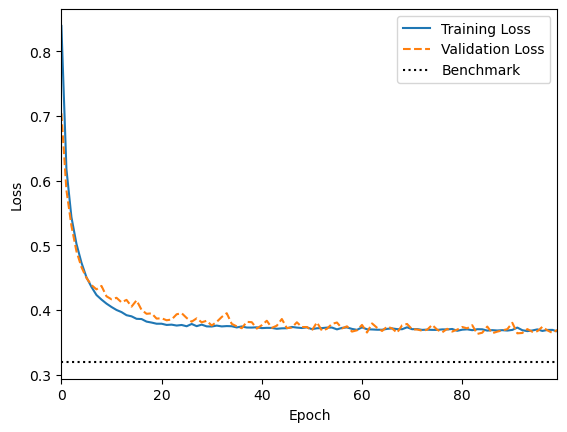

In [ ]:
plot_training(epochs, train_losses, val_losses, benchmark)

## Implementing the Recurrent Neural Network in a More Compact Form with Deeplay

Define a recurrent neural network in Deeplay ...

In [ ]:
# import deeplay as dl

# rnn_dl = dl.RecurrentModel(
#     in_features=n_features,
#     hidden_features=[2],
#     out_features=1,
#     rnn_type="RNN",
# )
# rnn_simple = dl.Regressor(rnn_dl, optimizer=dl.Adam(lr=0.001)).create()

... print out the application architecture ...

In [ ]:
# print(rnn_simple)

... and train it.

In [ ]:
# trainer = dl.Trainer(max_epochs=epochs, accelerator="auto")
# trainer.fit(rnn_simple, train_loader, val_loader)

# train_losses = trainer.history.history["train_loss_epoch"]["value"]
# val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]
# plot_training(epochs, train_losses, val_losses, benchmark)

## Stacking Multiple Recurrent Layers

In [ ]:
# M = 5

# rnn_dl = dl.RecurrentModel(
#     in_features=n_features,
#     hidden_features=[16, 16, 16],
#     out_features=1,
#     rnn_type="RNN",
#     embedding= torch.nn.Embedding(M, n_features)
# )
# rnn_stacked = dl.Regressor(rnn_dl, optimizer=dl.Adam(lr=0.0001)).create()

# trainer = dl.Trainer(max_epochs=epochs, accelerator="auto")
# trainer.fit(rnn_stacked, train_loader, val_loader)

# train_losses = trainer.history.history["train_loss_epoch"]["value"]
# val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]
# plot_training(epochs, train_losses, val_losses, benchmark)